### IMPORT LIBRARIES

In [4]:
import pandas as pd
import numpy as np
import re
import warnings

warnings.filterwarnings("ignore")

# NLP
import nltk
from nltk.corpus import stopwords
# nltk.download('stopwords')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


### LOAD DATA

In [5]:
df = pd.read_csv(r'C:\Users\anupa\Desktop\Python Learning\Text Analytics\reviews.csv')
pd.set_option('display.max_columns', None)
print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (568454, 10)
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of t

### TEXT CLEANING

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    Clean text by:
    - Lowercasing
    - Removing special characters
    - Removing stopwords
    """
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['Text'].apply(clean_text)


### CREATE SENTIMENT LABELS

In [7]:
def get_sentiment(score):
    """
    Convert rating into sentiment
    """
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['Score'].apply(get_sentiment)

### EXPLORATORY DATA ANALYSIS

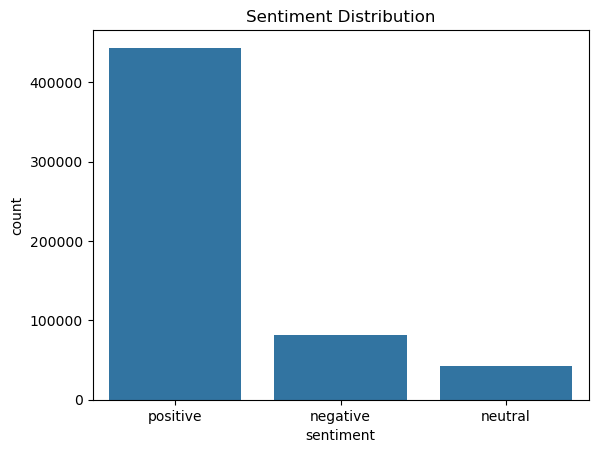

In [8]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()


### WORD CLOUD

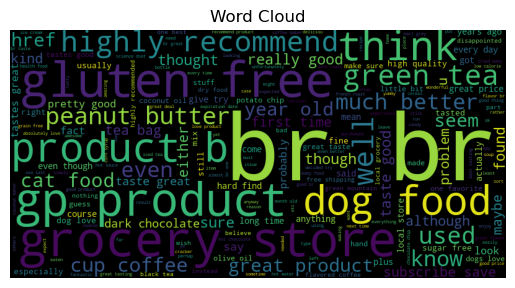

In [9]:
text = " ".join(df['clean_review'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()


### FEATURE ENGINEERING (TF-IDF)

Convert text into numerical features.

In [10]:
vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df['clean_review'])
y = df['sentiment']

### TRAIN-TEST SPLIT

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### TRAIN MULTIPLE MODELS

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)


Logistic Regression
Accuracy: 0.8625045078326341

Naive Bayes
Accuracy: 0.8108381490179521

SVM
Accuracy: 0.8604287058782137


### MODEL COMPARISON

In [13]:
results_df = pd.DataFrame(results.items(), columns=['Model', 'Accuracy'])
print("\nModel Comparison:")
print(results_df.sort_values(by='Accuracy', ascending=False))




Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.862505
2                  SVM  0.860429
1          Naive Bayes  0.810838


### BEST MODEL (LOGISTIC)

In [14]:
best_model = LogisticRegression(max_iter=200)
best_model.fit(X_train, y_train)

pred = best_model.predict(X_test)

print("\nClassification Report (Multiclass):")
print(classification_report(y_test, pred))


Classification Report (Multiclass):
              precision    recall  f1-score   support

    negative       0.73      0.66      0.69     16407
     neutral       0.51      0.17      0.25      8528
    positive       0.89      0.97      0.93     88756

    accuracy                           0.86    113691
   macro avg       0.71      0.60      0.62    113691
weighted avg       0.84      0.86      0.84    113691



### Binary Classification (Remove Neutral)

In [15]:

df_binary = df[df['sentiment'] != 'neutral']

X_bin = vectorizer.fit_transform(df_binary['clean_review'])
y_bin = df_binary['sentiment']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

model_bin = LogisticRegression(max_iter=200)
model_bin.fit(X_train_b, y_train_b)

pred_bin = model_bin.predict(X_test_b)

print("\nBinary Accuracy:", accuracy_score(y_test_b, pred_bin))



Binary Accuracy: 0.9267898405332674


### Prediction Function

In [16]:
def predict_sentiment(text_input, model, vectorizer):
    """
    Predict sentiment for new text input
    """
    if isinstance(text_input, str):
        text_input = [text_input]

    cleaned = [clean_text(text) for text in text_input]
    text_vec = vectorizer.transform(cleaned)

    return model.predict(text_vec)


### APPLY PREDICTIONS (BINARY)

In [17]:
df_binary['predicted'] = predict_sentiment(
    df_binary['Text'].tolist(),
    model_bin,
    vectorizer
)

print(df_binary[['sentiment', 'predicted']].head())

  sentiment predicted
0  positive  positive
1  negative  negative
2  positive  positive
3  negative  positive
4  positive  positive


### EVALUATION (BINARY)

In [18]:

accuracy = accuracy_score(df_binary['sentiment'], df_binary['predicted'])
print("\nBinary Accuracy (Full Data):", accuracy)

print("\nClassification Report (Binary):")
print(classification_report(df_binary['sentiment'], df_binary['predicted']))



Binary Accuracy (Full Data): 0.9288874012483502

Classification Report (Binary):
              precision    recall  f1-score   support

    negative       0.84      0.68      0.75     82037
    positive       0.94      0.98      0.96    443777

    accuracy                           0.93    525814
   macro avg       0.89      0.83      0.85    525814
weighted avg       0.93      0.93      0.93    525814



### CONFUSION MATRIX

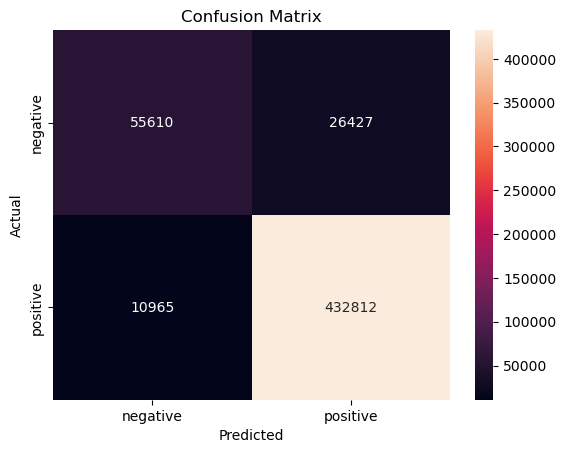

In [19]:

labels = ['negative', 'positive']

cm = confusion_matrix(
    df_binary['sentiment'],
    df_binary['predicted'],
    labels=labels
)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### WRONG PREDICTIONS

In [20]:
wrong_preds = df_binary[
    df_binary['sentiment'] != df_binary['predicted']
]

print("\nWrong Predictions Sample:")
print(wrong_preds[['Text', 'sentiment', 'predicted']].head())




Wrong Predictions Sample:
                                                 Text sentiment predicted
3   If you are looking for the secret ingredient i...  negative  positive
12  My cats have been happily eating Felidae Plati...  negative  positive
16  I love eating them and they are good for watch...  negative  positive
25  Product received is as advertised.<br /><br />...  positive  negative
26  The candy is just red , No flavor . Just  plan...  negative  positive


### CONFIDENCE SCORES

In [21]:
probs = model_bin.predict_proba(
    vectorizer.transform(df_binary['clean_review'])
)

df_binary['confidence'] = probs.max(axis=1)

print(df_binary[['Text', 'confidence']].head())

                                                Text  confidence
0  I have bought several of the Vitality canned d...    0.846840
1  Product arrived labeled as Jumbo Salted Peanut...    0.755407
2  This is a confection that has been around a fe...    0.986821
3  If you are looking for the secret ingredient i...    0.764615
4  Great taffy at a great price.  There was a wid...    0.999830
